In [1]:
#import likely useful libraries
import numpy as np
import pandas as pd
import datetime as dt
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#confirm directory
os.listdir()

['.ipynb_checkpoints',
 'corr_heatmap.png',
 'create_source.png',
 'logins.json',
 'ultimate_data_challenge.json',
 'ultimate_data_science_challenge (1).pdf',
 'ultimate_part1.ipynb',
 'Ultimate_part2.ipynb']

In [3]:
#import data
df = pd.read_json('ultimate_data_challenge.json')

#overview of data
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [4]:
#check column data types and for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


signup_date and last_trip_date are object types. we will convert these to datetime objects. avg_rating_of_driver, phone, and avg_rating_by_driver have missing values. We will investigate the NaNs later. first we will create a new column with the target feature "retained"

In [5]:
#convert to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

In [6]:
#create new column retained 
df['retained'] = (df['last_trip_date'] >= '2014-06-30').astype(int)

df.tail()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained
49995,King's Landing,0,2014-01-25,5.0,1.0,2014-06-05,iPhone,0.0,False,100.0,5.63,4.2,0
49996,Astapor,1,2014-01-24,NaN,1.0,2014-01-25,iPhone,0.0,False,0.0,0.00,4.0,0
49997,Winterfell,0,2014-01-31,5.0,1.0,2014-05-22,Android,0.0,True,100.0,3.86,5.0,0
49998,Astapor,2,2014-01-14,3.0,1.0,2014-01-15,iPhone,0.0,False,100.0,4.58,3.5,0
49999,Astapor,0,2014-01-18,NaN,1.0,2014-04-20,Android,0.0,False,0.0,3.49,5.0,0


Now we can start addressing the missing values in the columns. 

In [27]:
#see if there are any missing rows that also are also True in the retained feature
print(df[df['phone'].isna() & (df['retained']==1)].shape[0])
print(df[df['avg_rating_of_driver'].isna() & (df['retained']==1)].shape[0])
print(df[df['avg_rating_by_driver'].isna() & (df['retained']==1)].shape[0])

10
55
0


Since most of the missing values belong to "not-retained," we can learn from the missingness itself.
Since the phone feature is categorical, we can add a third category "missing."
For the ratings, we will create a secondary missingness column, then fill the original column with the median.

In [28]:
#impute NaNs with 'missing'
df['phone']=df['phone'].fillna('Missing')
df['phone'].value_counts()

phone
iPhone     34582
Android    15022
Missing      396
Name: count, dtype: int64

In [29]:
#create missingness column
df['avg_rating_of_driver_missing'] = df['avg_rating_of_driver'].isna().astype(int)

#impute NaNs with 'median'
df['avg_rating_of_driver'] = df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].median())

#create missingness column
df['rated_by_driver'] = df['avg_rating_by_driver'].isna().astype(int)

#impute NaNs with 'median'
df['avg_rating_by_driver'] = df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].median())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   city                          50000 non-null  object        
 1   trips_in_first_30_days        50000 non-null  int64         
 2   signup_date                   50000 non-null  datetime64[ns]
 3   avg_rating_of_driver          50000 non-null  float64       
 4   avg_surge                     50000 non-null  float64       
 5   last_trip_date                50000 non-null  datetime64[ns]
 6   phone                         50000 non-null  object        
 7   surge_pct                     50000 non-null  float64       
 8   ultimate_black_user           50000 non-null  bool          
 9   weekday_pct                   50000 non-null  float64       
 10  avg_dist                      50000 non-null  float64       
 11  avg_rating_by_driver        

Now that the data is cleaned, we can do EDA

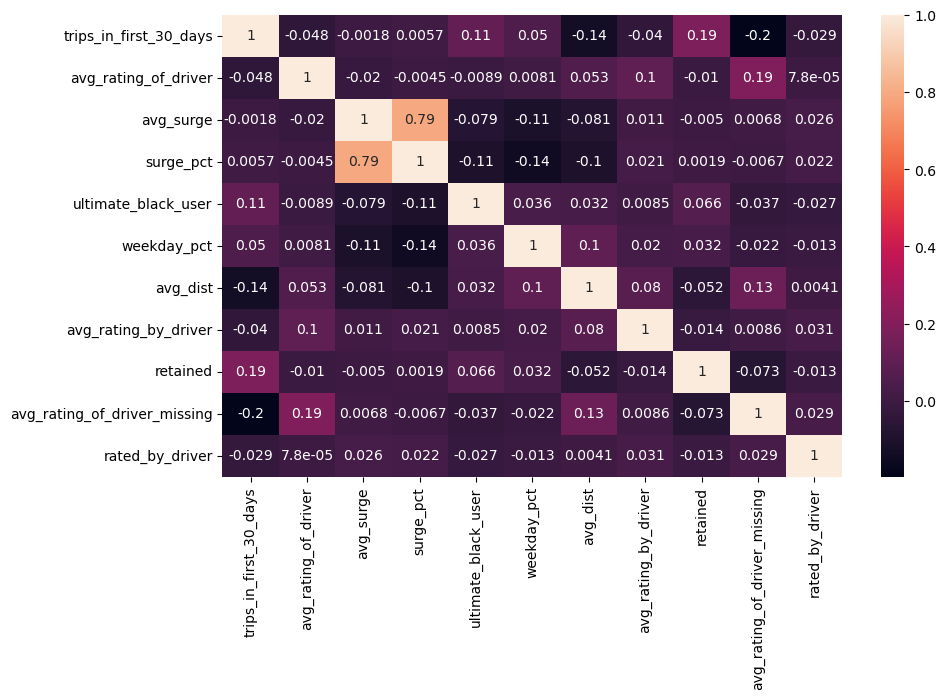

In [30]:
#we can start with a heatmap for numeric data
import scipy.stats as stats

corr = df.corr(numeric_only=True)

# Plot heatmap 
plt.figure(figsize=(10, 6)) 
sns.heatmap(corr, annot=True) 
plt.savefig("corr_heatmap.png", bbox_inches="tight")
plt.show()

Now we can look at categorical features

In [32]:
#create a function to look at categorical features
def plot_categorical_eda(df, cat_col, target_col='retained'):
    """
    Creates a 3‑panel EDA visualization for a categorical feature:
    1. Mean target rate by category
    2. Countplot with target hue
    3. Stacked percentage bar chart
    """

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    #barplot
    sns.barplot(data=df, x=cat_col, y=target_col, ax=axes[0], estimator='mean')
    axes[0].set_title(f'{target_col.capitalize()} Rate by {cat_col.capitalize()}')
    axes[0].set_ylabel(f'{target_col.capitalize()} Rate')

    #Countplot with hue
    sns.countplot(data=df, x=cat_col, hue=target_col, ax=axes[1])
    axes[1].set_title(f'{target_col.capitalize()} Count by {cat_col.capitalize()}')
    axes[1].set_ylabel('Count')

    #Stacked percentage bar chart
    ct = pd.crosstab(df[cat_col], df[target_col], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[2])
    axes[2].set_title(f'Percentage of {target_col.capitalize()} by {cat_col.capitalize()}')
    axes[2].set_ylabel('Proportion')
    axes[2].legend(['Not Retained', 'Retained'])

    plt.tight_layout()
    plt.show()


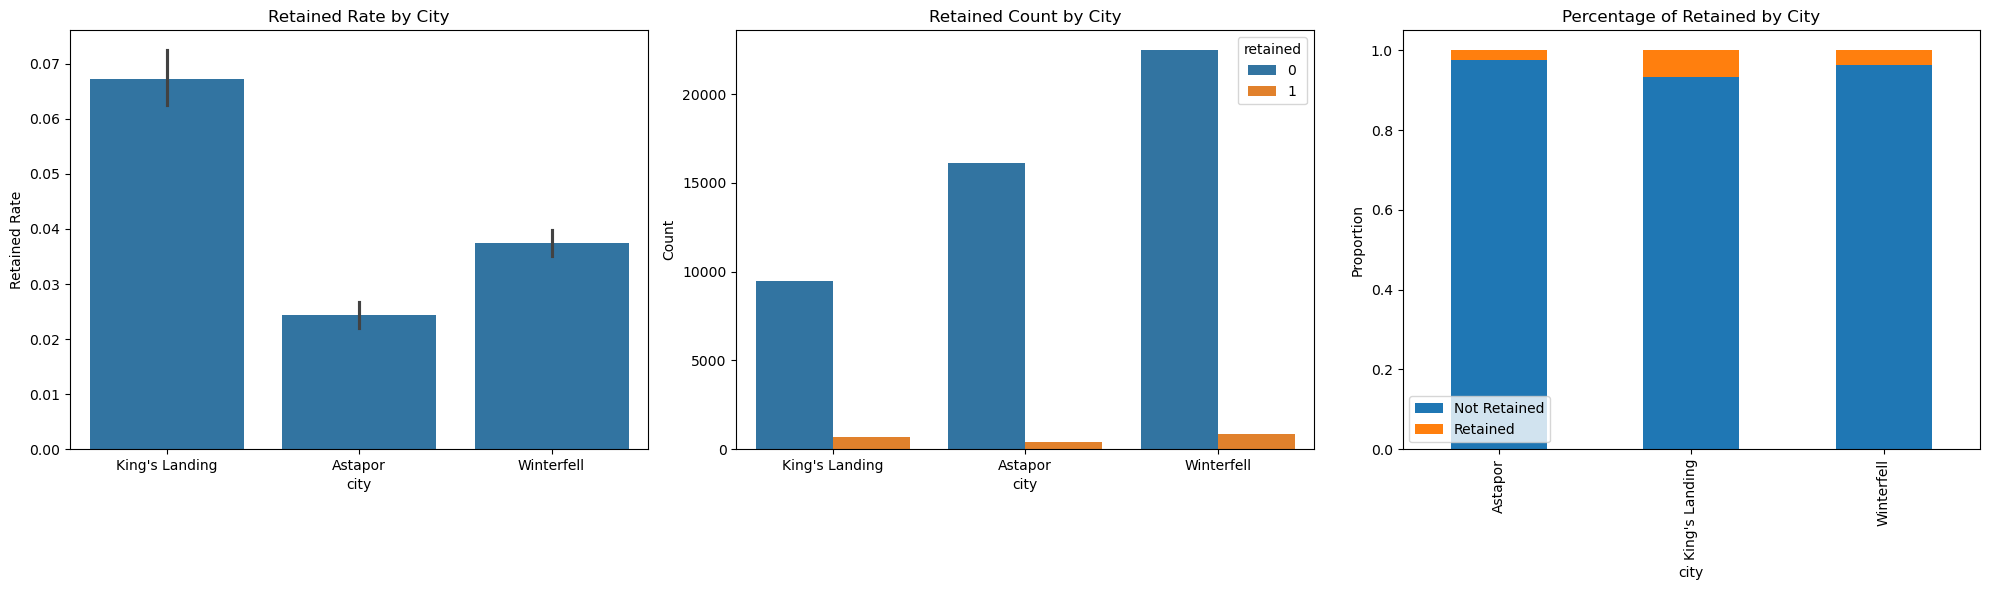

In [33]:
plot_categorical_eda(df, 'city')

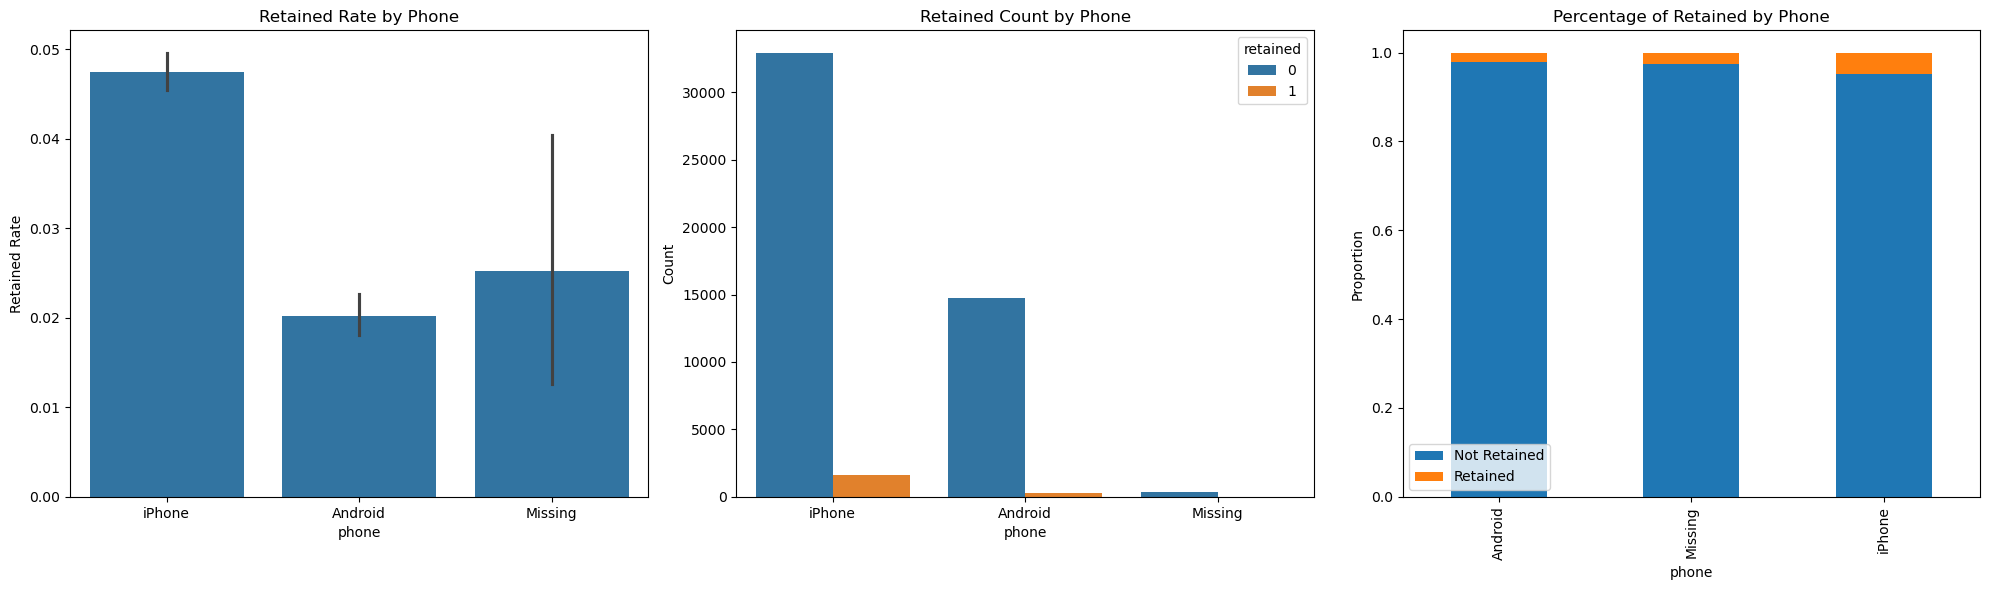

In [34]:
plot_categorical_eda(df, 'phone')

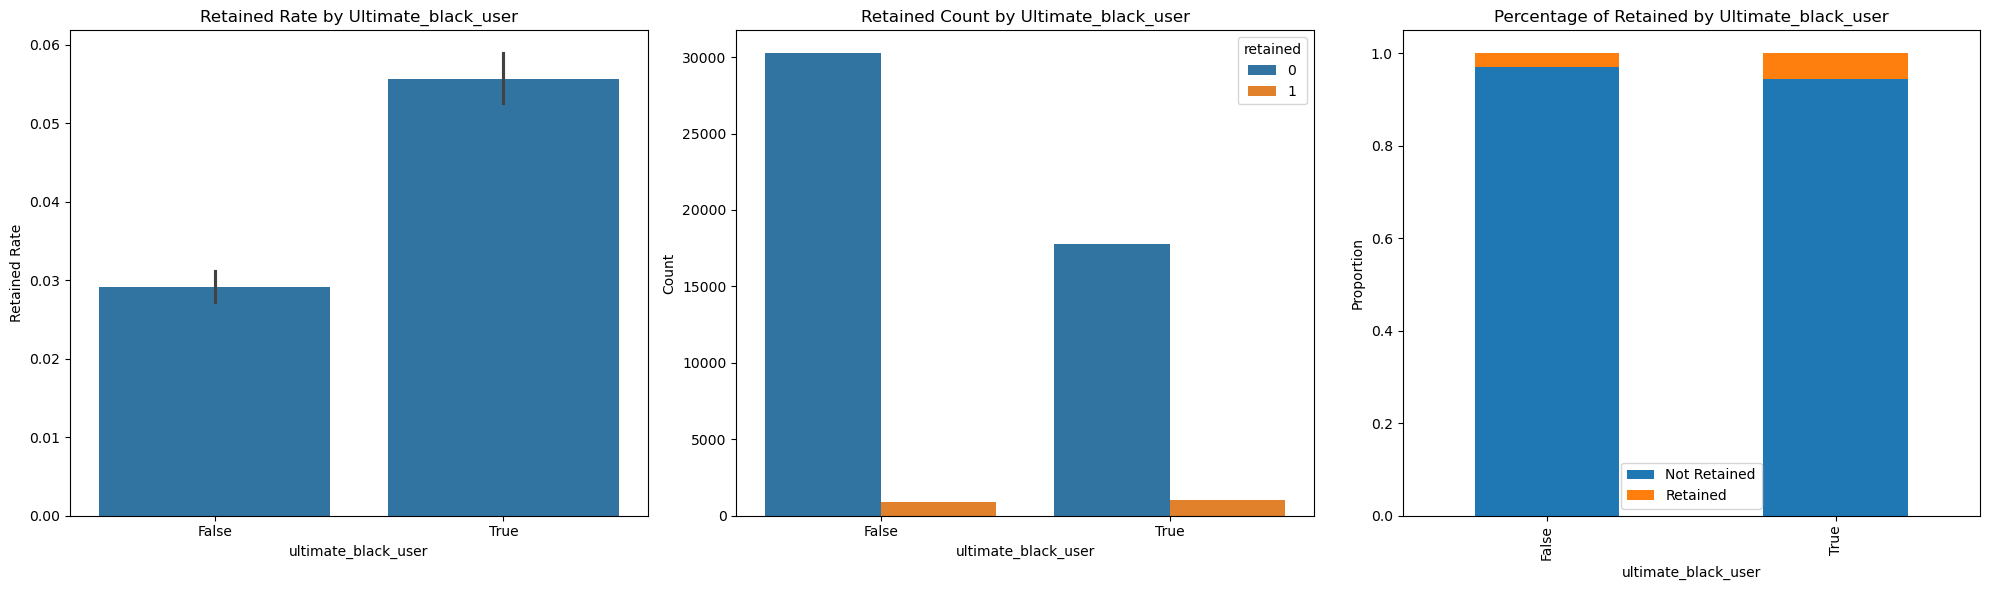

In [36]:
plot_categorical_eda(df, 'ultimate_black_user')

Now to preprocess the data